In [1]:
# Crear y explorar dataset de empleados
import pandas as pd
import numpy as np

# Crear dataset de empleados
np.random.seed(42)
n_empleados = 500

df = pd.DataFrame({
    'id_empleado': range(1, n_empleados + 1),
    'edad': np.random.normal(35, 8, n_empleados).clip(22, 65).astype(int),
    'salario': np.random.lognormal(10.5, 0.4, n_empleados).round(0),
    'años_experiencia': np.random.normal(8, 4, n_empleados).clip(0, 30).astype(int),
    'departamento': np.random.choice(['IT', 'Ventas', 'Marketing', 'RRHH', 'Finanzas'], n_empleados),
    'nivel': np.random.choice(['Junior', 'Senior', 'Lead', 'Manager'], n_empleados, p=[0.4, 0.4, 0.15, 0.05])
})

print(f"Dataset creado: {df.shape[0]} empleados")
print(f"Columnas: {list(df.columns)}")
df

Dataset creado: 500 empleados
Columnas: ['id_empleado', 'edad', 'salario', 'años_experiencia', 'departamento', 'nivel']


,id_empleado,edad,salario,años_experiencia,departamento,nivel
0,1,38,52600.0,13,RRHH,Junior
1,2,33,77946.0,11,RRHH,Senior
2,3,40,20756.0,8,Marketing,Lead
3,4,47,45487.0,5,IT,Senior
4,5,33,27994.0,10,Marketing,Junior
...,...,...,...,...,...,...
495,496,39,32453.0,16,Marketing,Junior
496,497,26,74539.0,16,Finanzas,Senior
497,498,33,46926.0,12,IT,Lead
498,499,27,28898.0,12,RRHH,Junior


In [2]:
# Análisis de medidas de tendencia central
# Estadísticos básicos
print("MEDIDAS DE TENDENCIA CENTRAL")
print("=" * 40)

# Variables numéricas
for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    print(f"  Media: {df[col].mean():.2f}")
    print(f"  Mediana: {df[col].median():.2f}")
    print(f"  Moda: {df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'Sin moda única'}")

# Variables categóricas
print(f"\nDEPARTAMENTO MÁS COMÚN: {df['departamento'].mode().iloc[0]}")
print(f"NIVEL MÁS COMÚN: {df['nivel'].mode().iloc[0]}")

MEDIDAS DE TENDENCIA CENTRAL

EDAD:
  Media: 34.69
  Mediana: 35.00
  Moda: 35

SALARIO:
  Media: 39715.18
  Mediana: 36732.00
  Moda: 23566.0

AÑOS_EXPERIENCIA:
  Media: 7.97
  Mediana: 8.00
  Moda: 8

DEPARTAMENTO MÁS COMÚN: RRHH
NIVEL MÁS COMÚN: Senior


In [3]:
# Análisis de dispersión
print("\n\nMEDIDAS DE DISPERSIÓN")
print("=" * 30)

for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    print(f"  Rango: {df[col].max() - df[col].min()}")
    print(f"  Varianza: {df[col].var():.2f}")
    print(f"  Desviación estándar: {df[col].std():.2f}")
    print(f"  Coeficiente de variación: {df[col].std() / df[col].mean():.3f}")



MEDIDAS DE DISPERSIÓN

EDAD:
  Rango: 43
  Varianza: 57.44
  Desviación estándar: 7.58
  Coeficiente de variación: 0.218

SALARIO:
  Rango: 91736.0
  Varianza: 262243168.52
  Desviación estándar: 16193.92
  Coeficiente de variación: 0.408

AÑOS_EXPERIENCIA:
  Rango: 18
  Varianza: 15.57
  Desviación estándar: 3.95
  Coeficiente de variación: 0.495


In [4]:
# Análisis de percentiles y distribución
print("\n\nANÁLISIS DE PERCENTILES")
print("=" * 25)

for col in ['edad', 'salario', 'años_experiencia']:
    print(f"\n{col.upper()}:")
    percentiles = df[col].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    for p, v in percentiles.items():
        print(f"  P{int(p*100)}: {v:.2f}")
    
    # Rango intercuartílico
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    print(f"  IQR: {iqr:.2f}")
    
    # Límites para outliers
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    print(f"  Outliers (IQR): {outliers}")



ANÁLISIS DE PERCENTILES

EDAD:
  P10: 25.00
  P25: 29.00
  P50: 35.00
  P75: 40.00
  P90: 45.00
  IQR: 11.00
  Outliers (IQR): 2

SALARIO:
  P10: 21990.90
  P25: 28620.75
  P50: 36732.00
  P75: 47121.75
  P90: 61840.40
  IQR: 18501.00
  Outliers (IQR): 19

AÑOS_EXPERIENCIA:
  P10: 3.00
  P25: 5.00
  P50: 8.00
  P75: 11.00
  P90: 13.00
  IQR: 6.00
  Outliers (IQR): 0


C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


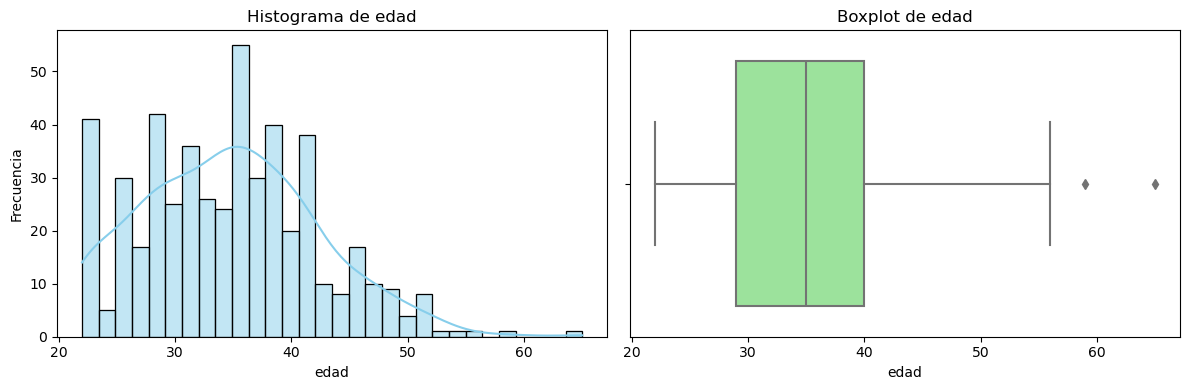

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


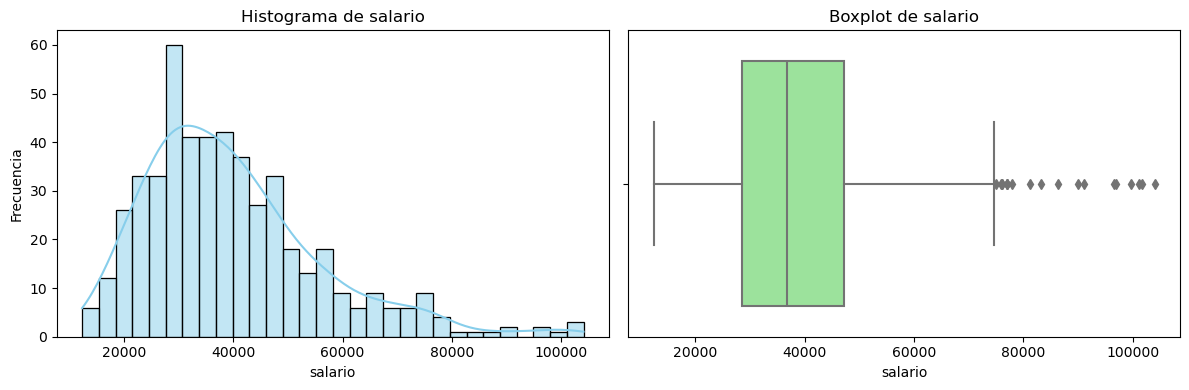

C:\Users\mfram\anaconda31\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


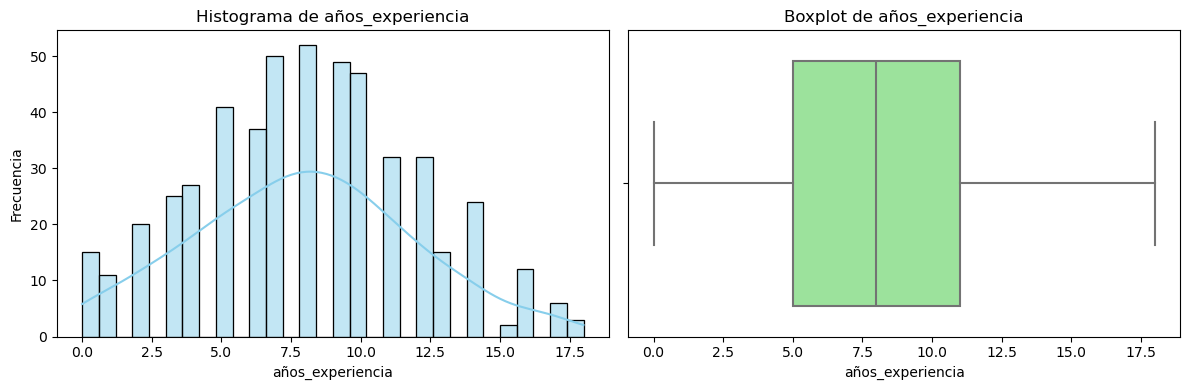

In [5]:
# ====================================
# Visualizaciones - Dataset empleados
# ====================================

import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas a graficar
columnas = ['edad', 'salario', 'años_experiencia']

for col in columnas:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    # Histograma con KDE
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f"Histograma de {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frecuencia")
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f"Boxplot de {col}")
    axes[1].set_xlabel(col)
    
    plt.tight_layout()
    plt.show()

In [6]:
# Análisis por categorías
print("\n\nANÁLISIS POR DEPARTAMENTO")
print("=" * 30)

dept_stats = df.groupby('departamento').agg({
    'salario': ['mean', 'median', 'std', 'count'],
    'edad': ['mean', 'min', 'max']
}).round(2)

print(dept_stats)

print("\n\nANÁLISIS POR NIVEL")
print("=" * 20)

nivel_stats = df.groupby('nivel').agg({
    'salario': 'mean',
    'años_experiencia': 'mean',
    'edad': 'mean'
}).round(2)

print(nivel_stats)



ANÁLISIS POR DEPARTAMENTO
               salario                            edad        
                  mean   median       std count   mean min max
departamento                                                  
Finanzas      39400.97  35745.0  17512.32    97  34.45  22  59
IT            39004.76  35310.0  16511.62   109  34.73  22  50
Marketing     39298.89  38299.0  14486.98   101  34.31  22  51
RRHH          40449.09  39102.0  14913.70   115  35.04  22  65
Ventas        40555.69  36957.5  18173.55    78  34.90  22  56


ANÁLISIS POR NIVEL
          salario  años_experiencia   edad
nivel                                     
Junior   39307.28              7.88  35.12
Lead     38850.40              8.37  34.92
Manager  40954.41              7.05  33.09
Senior   40309.09              7.96  34.38


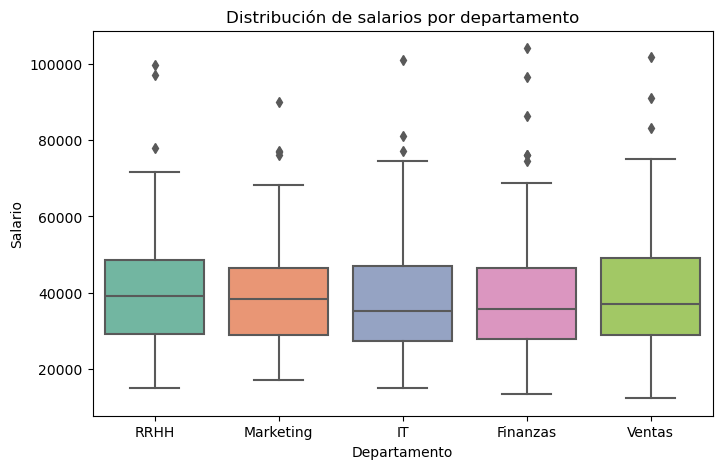

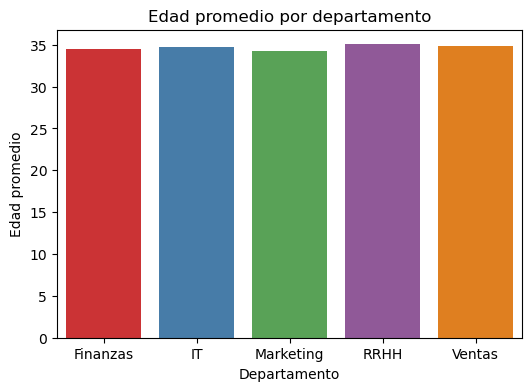

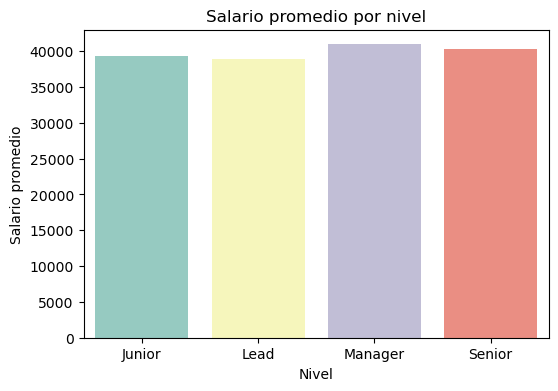

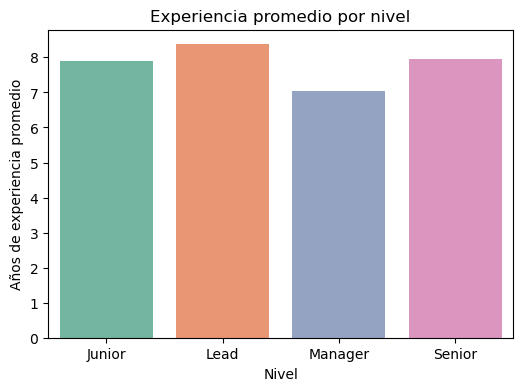

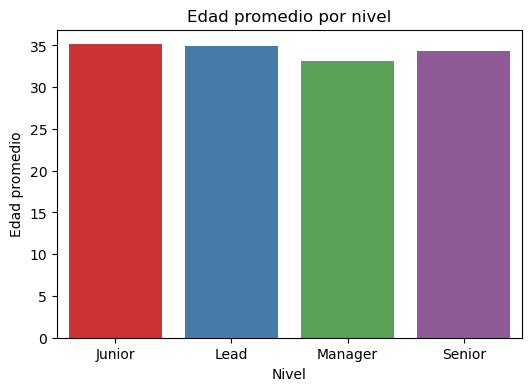

In [7]:
# ================================================
# Visualización por categorías - Dataset empleados
# ================================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Salario por departamento (boxplot) ---
plt.figure(figsize=(8,5))
sns.boxplot(x='departamento', y='salario', data=df, palette='Set2')
plt.title("Distribución de salarios por departamento")
plt.xlabel("Departamento")
plt.ylabel("Salario")
plt.show()

# 2. Edad promedio por departamento (barplot) ---
dept_age = df.groupby('departamento')['edad'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='departamento', y='edad', data=dept_age, palette='Set1')
plt.title("Edad promedio por departamento")
plt.xlabel("Departamento")
plt.ylabel("Edad promedio")
plt.show()

# 3. Salario promedio por nivel ---
nivel_salario = df.groupby('nivel')['salario'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='nivel', y='salario', data=nivel_salario, palette='Set3')
plt.title("Salario promedio por nivel")
plt.xlabel("Nivel")
plt.ylabel("Salario promedio")
plt.show()

# 4. Años de experiencia promedio por nivel ---
nivel_exp = df.groupby('nivel')['años_experiencia'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='nivel', y='años_experiencia', data=nivel_exp, palette='Set2')
plt.title("Experiencia promedio por nivel")
plt.xlabel("Nivel")
plt.ylabel("Años de experiencia promedio")
plt.show()

# 5. Edad promedio por nivel ---
nivel_edad = df.groupby('nivel')['edad'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='nivel', y='edad', data=nivel_edad, palette='Set1')
plt.title("Edad promedio por nivel")
plt.xlabel("Nivel")
plt.ylabel("Edad promedio")
plt.show()

In [ ]:
# Media: útil en análisis técnicos, comparaciones estadísticas y cuando los datos son homogéneos.
# Mediana: preferida en contextos con outliers, para storytelling ejecutivo y cuando se quiere mostrar 
# la “realidad típica” sin distorsiones.
# En el dataset de empleados, por ejemplo, los salarios tienen distribución lognormal con outliers altos. 
# Ahí la mediana es más representativa para describir al empleado promedio. 
# En cambio, para edad o años de experiencia, donde la distribución es más simétrica, la media funciona bien.